Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - accuracy: 0.7618 - loss: 0.6557 - val_accuracy: 0.8493 - val_loss: 0.4175
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 60ms/step - accuracy: 0.8401 - loss: 0.4433 - val_accuracy: 0.8696 - val_loss: 0.3499
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 57ms/step - accuracy: 0.8625 - loss: 0.3811 - val_accuracy: 0.8821 - val_loss: 0.3142
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 85s 61ms/step - accuracy: 0.8762 - loss: 0.3441 - val_accuracy: 0.8895 - val_loss: 0.3035
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 79s 57ms/step - accuracy: 0.8845 - loss: 0.3246 - val_accuracy: 0.8965 - val_loss: 0.2824
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 56ms/step - accuracy: 0.8900 - loss: 0.3043 - val_accuracy: 0.8983 - val_loss: 0.2731
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 57ms/step - accuracy: 0.8968 - loss: 0.2833 - val_accuracy: 0.9022 - val_loss: 0.2685
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 56ms/step - accuracy: 0.9009 - loss: 0.2730 - 

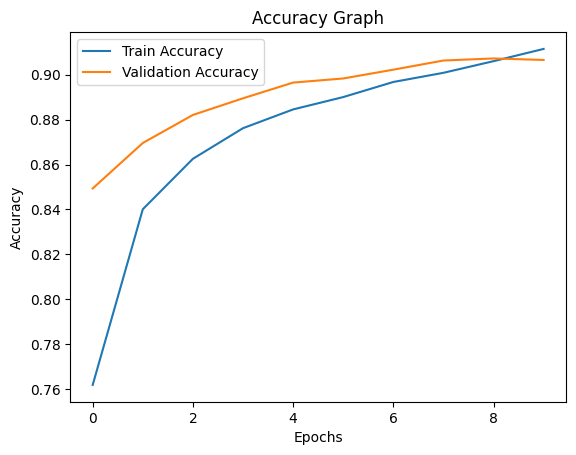

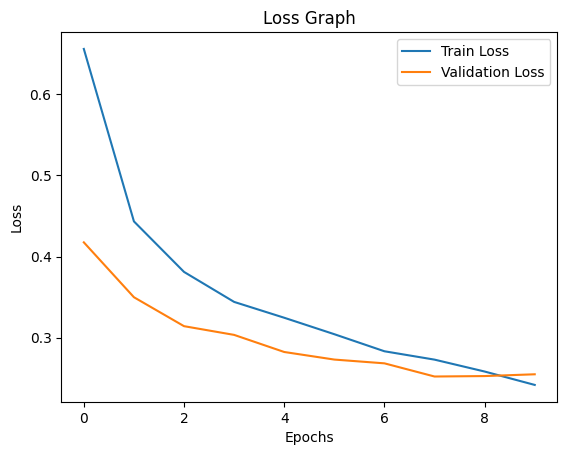

In [4]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
import matplotlib.pyplot as plt

# ==============================
# 2. LOAD DATASET
# ==============================
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training shape:", X_train.shape);
print("Testing shape:", X_test.shape);

# ==============================
# 3. PREPROCESSING
# ==============================
# Normalize
X_train = X_train / 255.0;
X_test = X_test / 255.0;

# Reshape for CNN (add channel dimension)
X_train = X_train.reshape(-1, 28, 28, 1);
X_test = X_test.reshape(-1, 28, 28, 1);

# ==============================
# 4. BUILD CNN MODEL
# ==============================
model = Sequential([
    Input(shape=(28,28,1)), # Add Input layer as recommended
    # Convolution Layer 1
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Convolution Layer 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Flatten
    Flatten(),

    # Fully Connected Layers
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Output Layer
    Dense(10, activation='softmax')
]);

# ==============================
# 5. COMPILE MODEL
# ==============================
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']);

# ==============================
# 6. TRAIN MODEL
# ==============================
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
);

# ==============================
# 7. EVALUATE MODEL
# ==============================
test_loss, test_acc = model.evaluate(X_test, y_test);
print("\nTest Accuracy:", test_acc);

# ==============================
# 8. PLOT ACCURACY GRAPH
# ==============================
plt.figure();
plt.plot(history.history['accuracy'], label='Train Accuracy');
plt.plot(history.history['val_accuracy'], label='Validation Accuracy');
plt.title('Accuracy Graph');
plt.xlabel('Epochs');
plt.ylabel('Accuracy');
plt.legend();
plt.show();

# ==============================
# 9. PLOT LOSS GRAPH
# ==============================
plt.figure();
plt.plot(history.history['loss'], label='Train Loss');
plt.plot(history.history['val_loss'], label='Validation Loss');
plt.title('Loss Graph');
plt.xlabel('Epochs');
plt.ylabel('Loss');
plt.legend();
plt.show();